In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 관련 ################################################
# 결측치 처리
from sklearn.impute import SimpleImputer
# 표준화
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
# 인코더
from sklearn.preprocessing import LabelEncoder
# 원핫 인코더
from sklearn.preprocessing import OneHotEncoder

# 학습 모델 성능 관련 #######################################
# 원하는 비율로 데이터를 나누기 위해
from sklearn.model_selection import train_test_split
# K-Fold 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
# 학습 곡선
from sklearn.model_selection import learning_curve
# 하이퍼 파라미터 튜닝
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 모델 성능 평가 ########################
# 회귀용
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
# 분류용
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

# 피처 선택 #########################
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance

# 학습 모델 ########################
# 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier 
from sklearn.naive_bayes import GaussianNB
from catboost import CatBoostClassifier

# 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import BayesianRidge
from catboost import CatBoostRegressor

# 결정트리를 시각화할 수 있는 라이브러리
from sklearn.tree import plot_tree

# 차원 축소
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE

# 연관 규칙 학습
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

# 군집
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.mixture import GaussianMixture
from sklearn.cluster import MeanShift, estimate_bandwidth

# 파이프라인
from sklearn.pipeline import Pipeline

# KDE를 그리기 위한 통계값을 구할 수 있는 함수
from scipy.stats import gaussian_kde

# 피어슨 상관 계수 (연속형 수치형 데이터 vs 연속형 수치형 데이터)
from scipy.stats import pearsonr
# 카이제곱 검증 (범주형 데이터 vs 범주형 데이터, 순위X)
from scipy.stats import chi2_contingency
# 스피어만 상관계수 (범주형 데이터 vs 범주형 데이터, 순위O)
from scipy.stats import spearmanr
# 포인트 이분 상관계수 (범주형 데이터 vs 연속형 수치형 데이터)
from scipy.stats import pointbiserialr

# 객체를 파일에 저장
import pickle

# 불필요한 경고 뜨지 않게
import warnings
warnings.filterwarnings('ignore')

### 데이터를 불러온다.

In [2]:
train_df = pd.read_csv('data/bike_sharing_train.csv')
train_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [3]:
test_df = pd.read_csv('data/bike_sharing_test.csv')
test_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014
...,...,...,...,...,...,...,...,...,...
6488,2012-12-31 19:00:00,1,0,1,2,10.66,12.880,60,11.0014
6489,2012-12-31 20:00:00,1,0,1,2,10.66,12.880,60,11.0014
6490,2012-12-31 21:00:00,1,0,1,1,10.66,12.880,60,11.0014
6491,2012-12-31 22:00:00,1,0,1,1,10.66,13.635,56,8.9981


- 결과 데이터로 사용 가능한 컬럼 : casual(비 회원 대여수), registered(회원 대여수), count(총 대여수)
- 본 프로젝트에서는 count를 예측할 것이다.
- casual과 registered는 제거한다

In [4]:
train_df.drop(['casual', 'registered'], axis=1, inplace=True)
train_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,1
...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,129


### count 데이터 분석

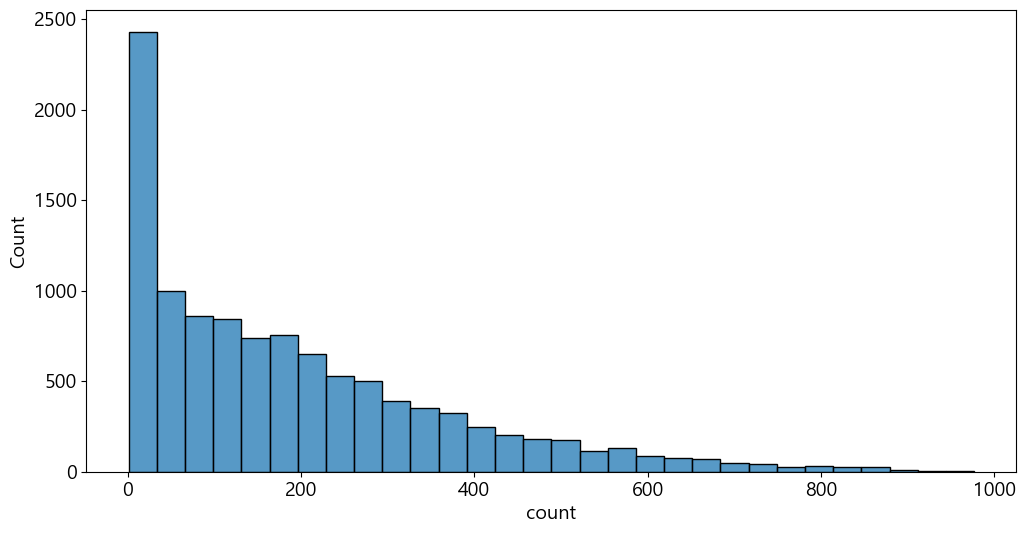

In [5]:
sns.histplot(data=train_df, x='count', bins=30)
plt.show()

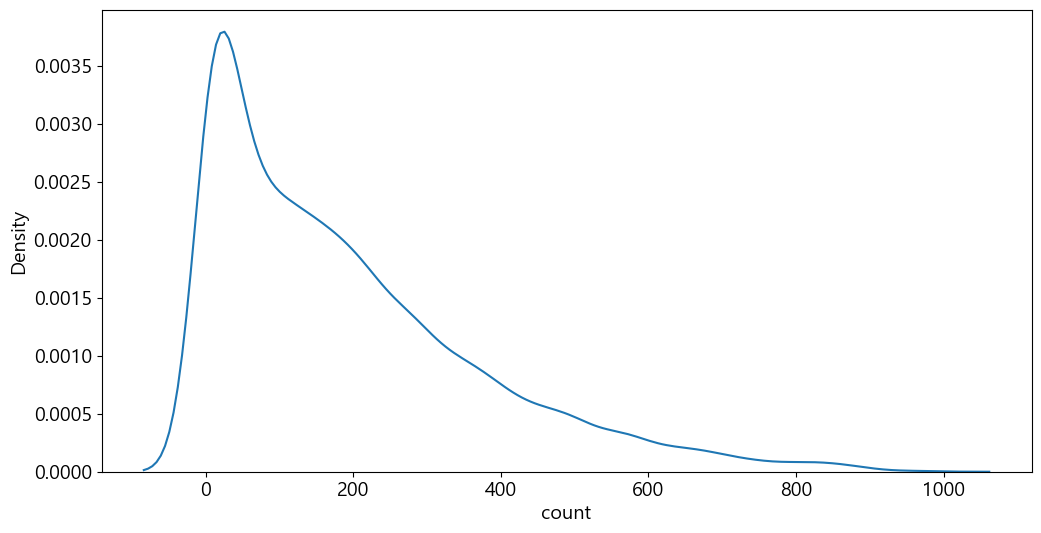

In [6]:
sns.kdeplot(data=train_df, x='count')
plt.show()

In [7]:
# 결과데이터가 한쪽으로 치우쳐져 있기 때문에 로그값을 구해서 담아준다.
train_df['log_count'] = np.log1p(train_df['count'])
train_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,log_count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,16,2.833213
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,40,3.713572
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,32,3.496508
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,13,2.639057
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,1,0.693147
...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,336,5.820083
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,241,5.488938
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,168,5.129899
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,129,4.867534


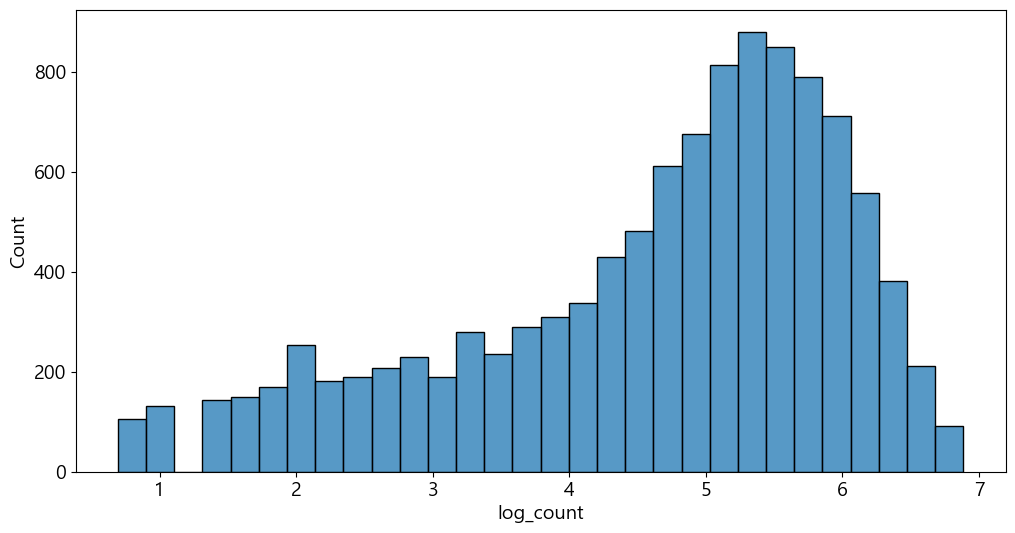

In [8]:
sns.histplot(data=train_df, x='log_count', bins=30)
plt.show()

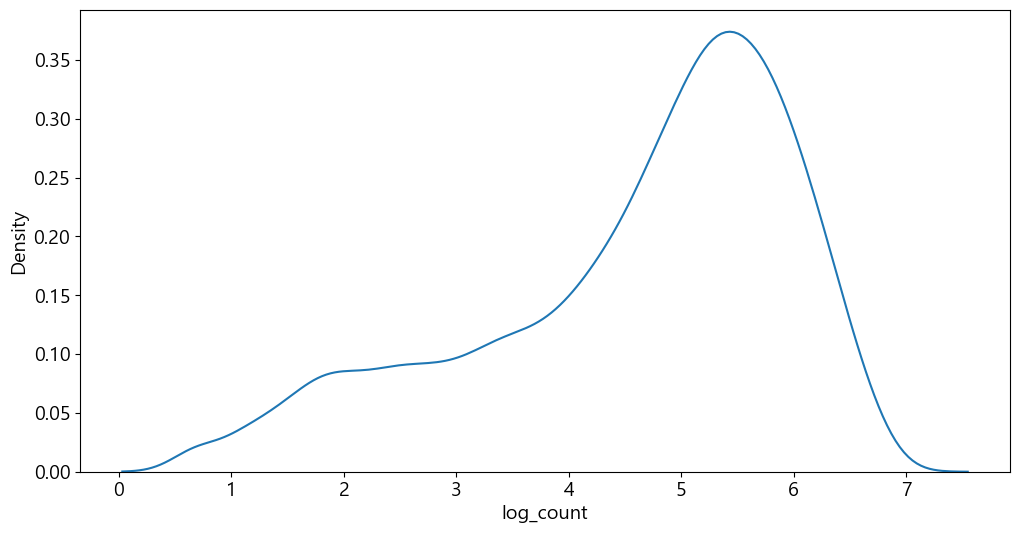

In [9]:
sns.kdeplot(data=train_df, x='log_count')
plt.show()

In [10]:
a1 = np.expm1(train_df['log_count'])
pd.DataFrame([a1, train_df['count']])

,0,1,2,3,4,5,6,7,8,9,...,10876,10877,10878,10879,10880,10881,10882,10883,10884,10885
log_count,16.0,40.0,32.0,13.0,1.0,1.0,2.0,3.0,8.0,14.0,...,218.0,237.0,334.0,562.0,569.0,336.0,241.0,168.0,129.0,88.0
count,16.0,40.0,32.0,13.0,1.0,1.0,2.0,3.0,8.0,14.0,...,218.0,237.0,334.0,562.0,569.0,336.0,241.0,168.0,129.0,88.0


### 시계열 데이터 분석

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [12]:
# 시계열 데이터 분해
# 1주일간의 패턴을 보기 위해 24 * 7 = 168을 설정한다.
decomposition = seasonal_decompose(train_df['log_count'], period=168)

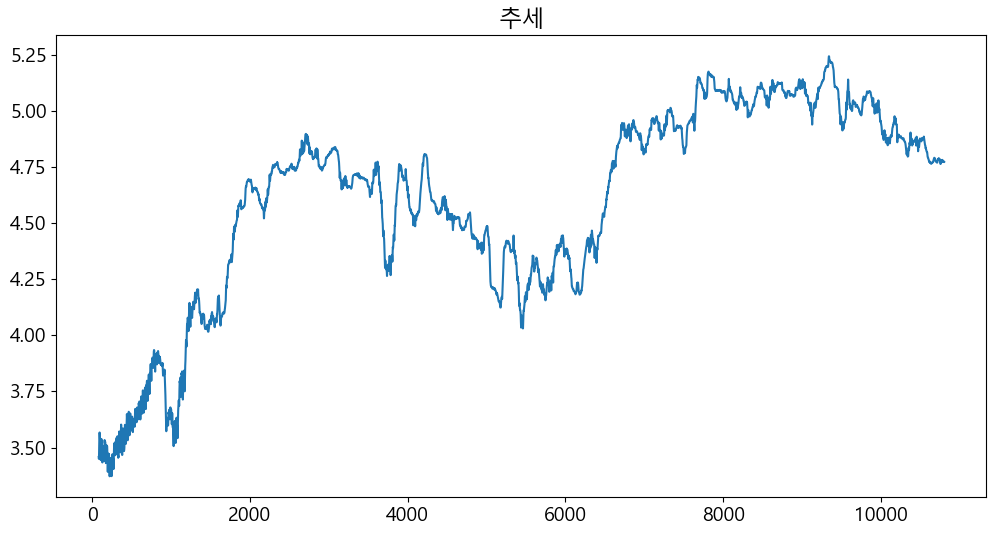

In [13]:
decomposition.trend.plot()
plt.title('추세')
plt.show()

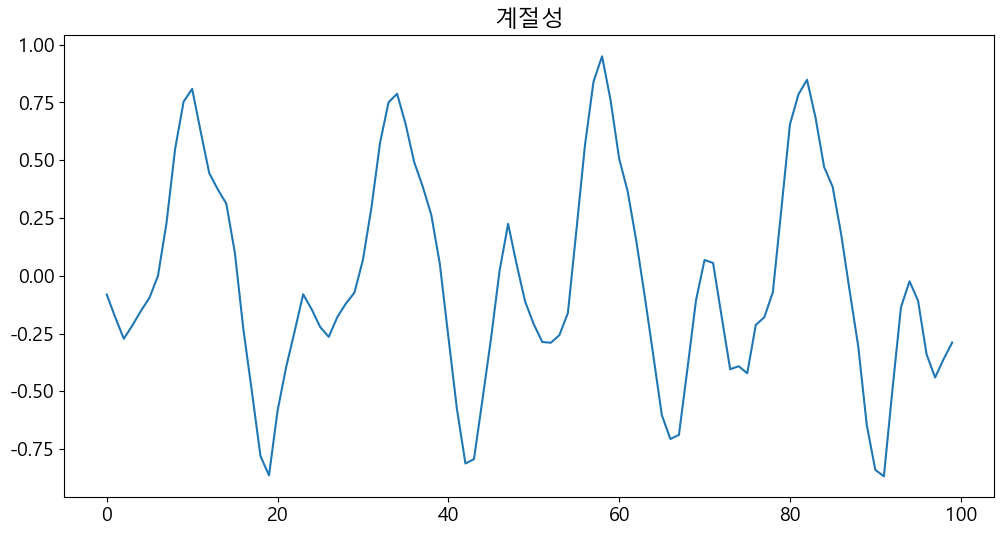

In [14]:
# 계절성
decomposition.seasonal[:100].plot()
plt.title('계절성')
plt.show()

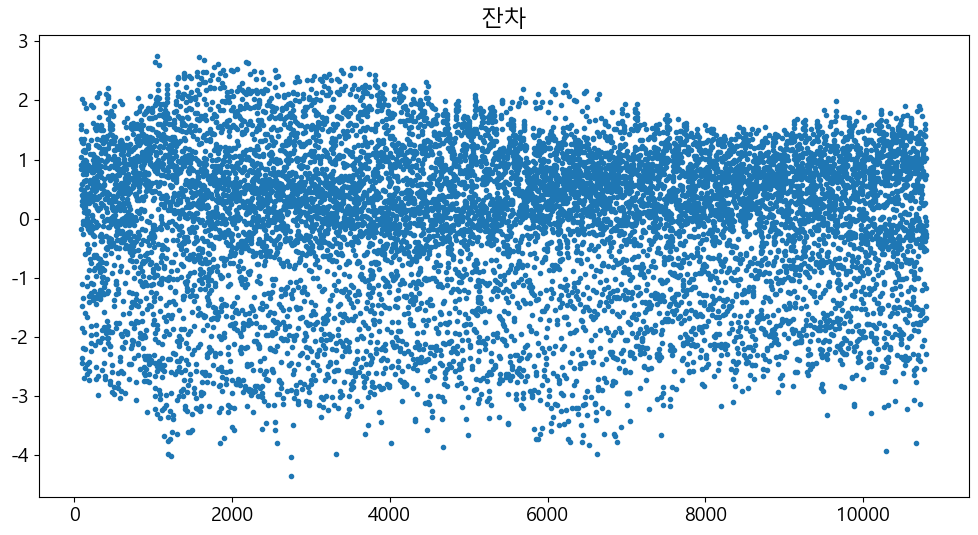

In [15]:
decomposition.resid.plot(style='.')
plt.title('잔차')
plt.show()

### datetime
- 일시, 시간, 단위의 날짜와 타임 스탬프
- 우리는 딥러닝이 아닌 전통적인 머신러닝을 사용할 것이다.
- 이에 각 행별로 결과데이터를 예측하는 회귀 분석을 수행할 것이다.
- 따라서 datetime을 년, 월, 일, 시로 분해하여 각각을 범주형 데이터로 사용할 것이다.

In [16]:
# datetime 컬럼을 날짜 타입으로 변경한다.
train_df['datetime'] = pd.to_datetime(train_df['datetime'])

# 년, 월, 일, 시 컬럼 생성
train_df['year'] = train_df['datetime'].dt.year
train_df['month'] = train_df['datetime'].dt.month
train_df['day'] = train_df['datetime'].dt.day
train_df['hour'] = train_df['datetime'].dt.hour

train_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,log_count,year,month,day,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,16,2.833213,2011,1,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,40,3.713572,2011,1,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,32,3.496508,2011,1,1,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,13,2.639057,2011,1,1,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,1,0.693147,2011,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,336,5.820083,2012,12,19,19
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,241,5.488938,2012,12,19,20
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,168,5.129899,2012,12,19,21
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,129,4.867534,2012,12,19,22


In [17]:
test_df['datetime'] = pd.to_datetime(test_df['datetime'])

test_df['year'] = test_df['datetime'].dt.year
test_df['month'] = test_df['datetime'].dt.month
test_df['day'] = test_df['datetime'].dt.day
test_df['hour'] = test_df['datetime'].dt.hour

test_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027,2011,1,20,0
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,1
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,2
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,3
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6488,2012-12-31 19:00:00,1,0,1,2,10.66,12.880,60,11.0014,2012,12,31,19
6489,2012-12-31 20:00:00,1,0,1,2,10.66,12.880,60,11.0014,2012,12,31,20
6490,2012-12-31 21:00:00,1,0,1,1,10.66,12.880,60,11.0014,2012,12,31,21
6491,2012-12-31 22:00:00,1,0,1,1,10.66,13.635,56,8.9981,2012,12,31,22


### season
- 계절
- 1 = 봄, 2 = 여름, 3 = 가을, 4 = 겨울

In [18]:
# 도수 분포 확인
a1 = train_df['season'].value_counts()
a1.sort_index(inplace=True)
a1.index = ['봄', '여름', '가을', '겨울']
a1

봄     2686
여름    2733
가을    2733
겨울    2734
Name: count, dtype: int64

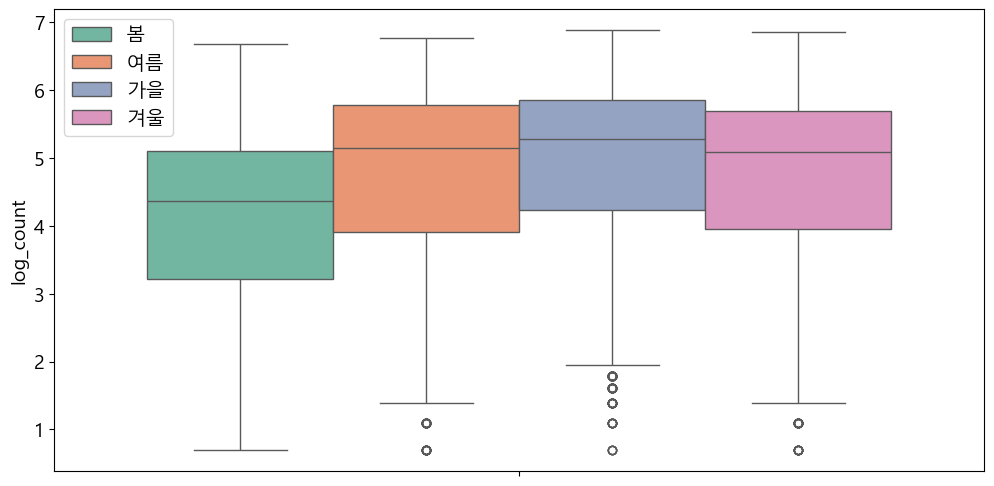

In [19]:
# season을 활용하여 boxplot을 그려본다.
sns.boxplot(data=train_df, y='log_count', hue='season', palette='Set2')
plt.legend(labels=['봄', '여름', '가을', '겨울'])
plt.show()

,season,log_count
2,3,4.885394
1,2,4.736112
3,4,4.684555
0,1,4.050051


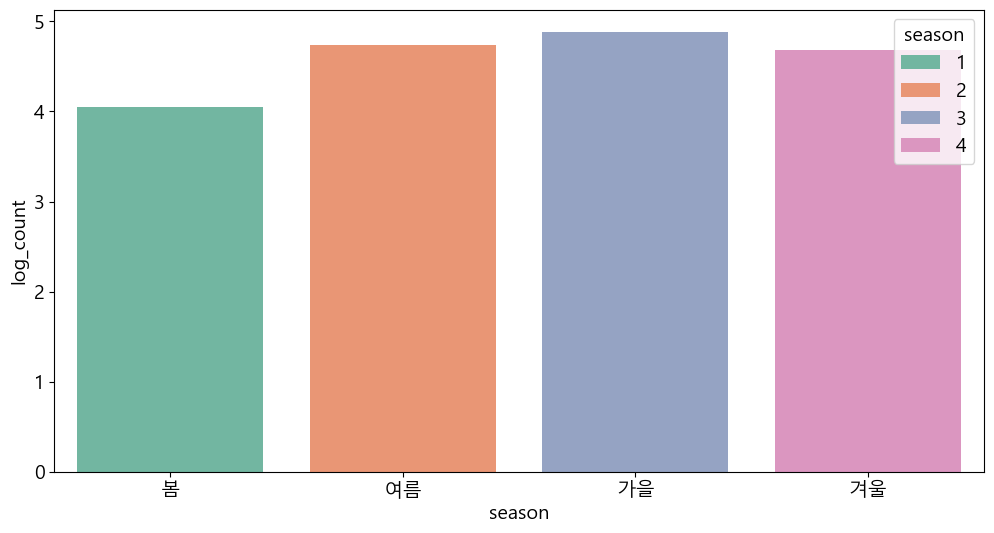

In [20]:
# season 별 log_count의 평균 시각화
a1 = train_df.groupby('season', as_index=False)['log_count'].mean()
a2 = a1.sort_values('log_count', ascending=False)
display(a2)

sns.barplot(data=a1, x='season', y='log_count', palette='Set2', hue='season')
plt.xticks([0, 1, 2, 3], ['봄', '여름', '가을', '겨울'])
plt.show()

- 봄이 가장 낮다.
- 봄에서 여름, 가을로 진행될 때 대여수가 증가하고 겨울에 감소한다

### holiday
- 공휴일 여부
- 1 = 공휴일, 0 = 평일

In [21]:
# 도수 분포 확인
train_df['holiday'].value_counts()

holiday
0    10575
1      311
Name: count, dtype: int64

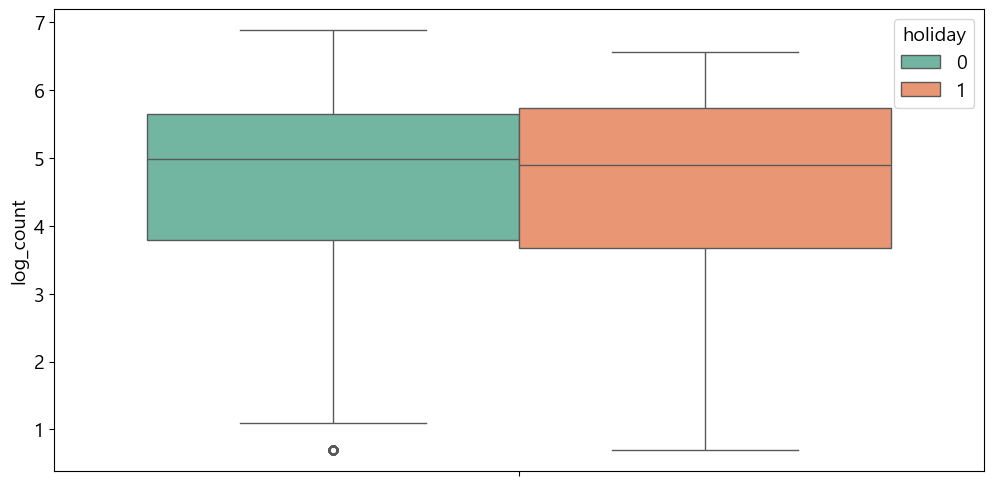

In [22]:
# holiday를 활용하여 boxplot을 그려본다.
sns.boxplot(data=train_df, y='log_count', hue='holiday', palette='Set2')
plt.show()

,holiday,log_count
0,0,4.591663
1,1,4.581175


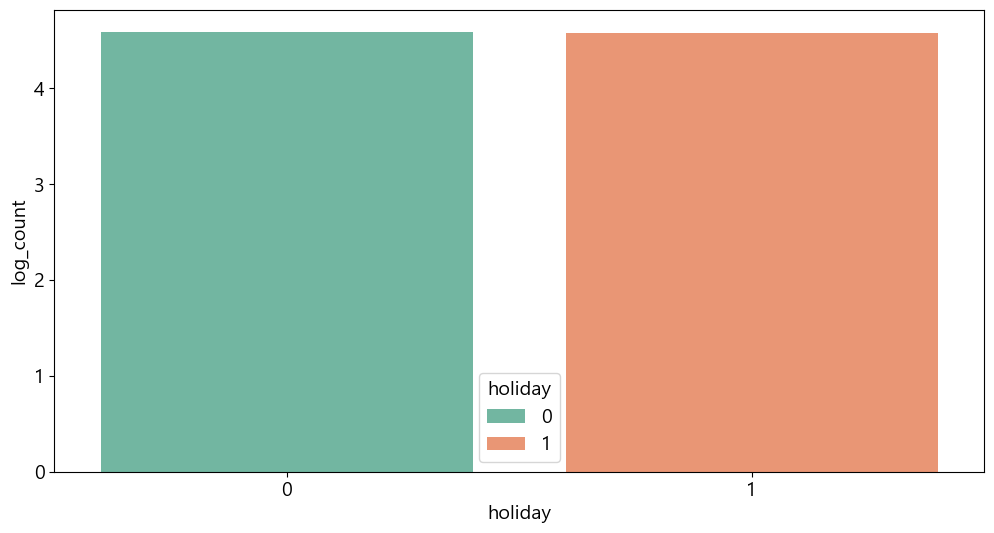

In [23]:
# holiday별 log_count 평균 시각화
a1 = train_df.groupby('holiday', as_index=False)['log_count'].mean()

a2 = a1.sort_values('log_count', ascending=False)
display(a2)

sns.barplot(data=a1, x='holiday', y='log_count', palette='Set2', hue='holiday')
plt.show()

- 공휴일인 날과 공휴일이 아닌 날의 자전거 대여 횟수는 큰 차이가 없다

### workingday 분석
- 근무일 여부
- 1 = 근무일, 0 = 휴일

In [24]:
# 도수 분포 확인
train_df['workingday'].value_counts()

workingday
1    7412
0    3474
Name: count, dtype: int64

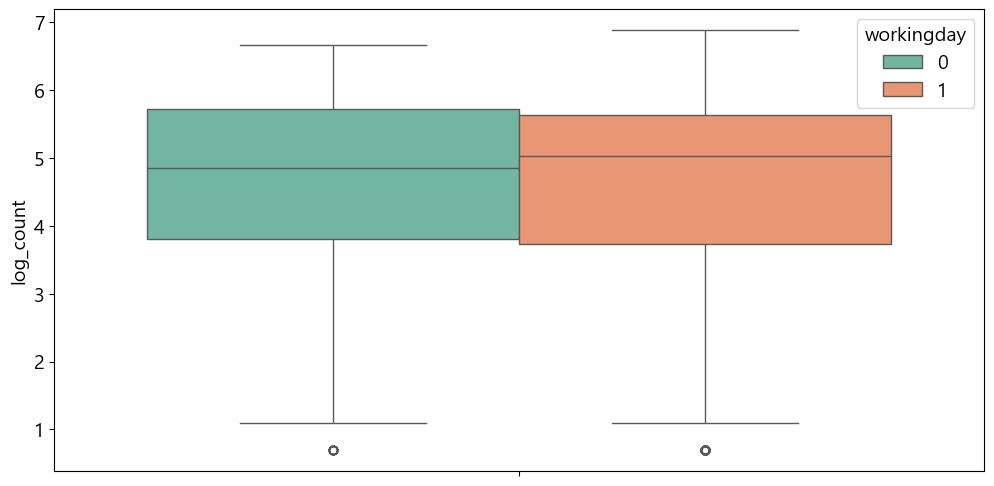

In [25]:
# workingday를 활용하여 boxplot을 그려본다.
sns.boxplot(data=train_df, y='log_count', hue='workingday', palette='Set2')
plt.show()

,workingday,log_count
0,0,4.623139
1,1,4.576470


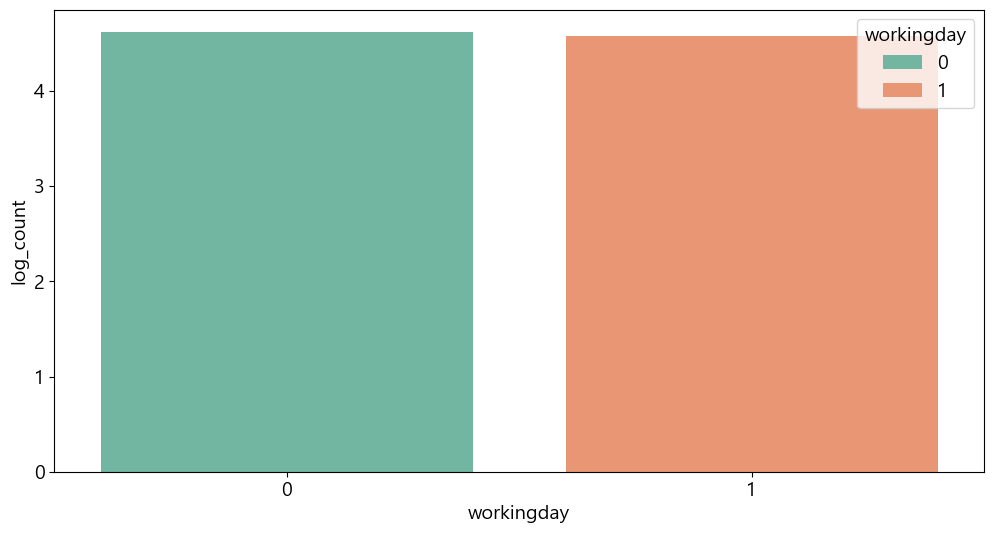

In [26]:
# workingday 별 log_count의 평균 시각화
a1 = train_df.groupby('workingday', as_index=False)['log_count'].mean()

a2 = a1.sort_values('log_count', ascending=False)
display(a2)

sns.barplot(data=a1, x='workingday', y='log_count', palette='Set2', hue='workingday')
plt.show()

- 업무일과 업무일이 아닌 날의 자전거 대여 횟수는 큰 차이를 보이지 않는다

###  weather 분석
- 날씨 상태
- 1 = 맑음, 2 = 흐림, 3 = 비/눈, 4 = 악천후

In [27]:
train_df['weather'].value_counts()

weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64

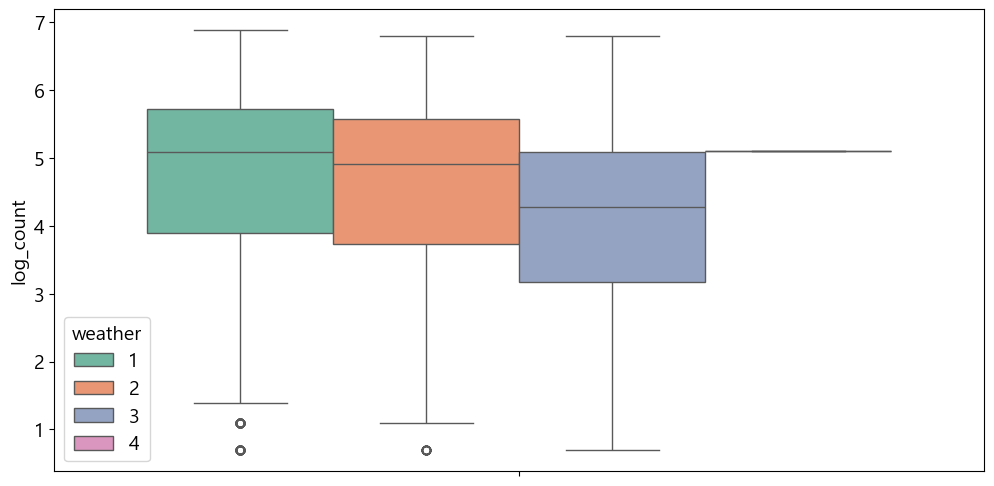

In [28]:
# weather를 활용하여 boxplot을 그려본다.
sns.boxplot(data=train_df, y='log_count', hue='weather', palette='Set2')
plt.show()

,weather,log_count
3,4,5.105945
0,1,4.673980
1,2,4.545450
2,3,4.050533


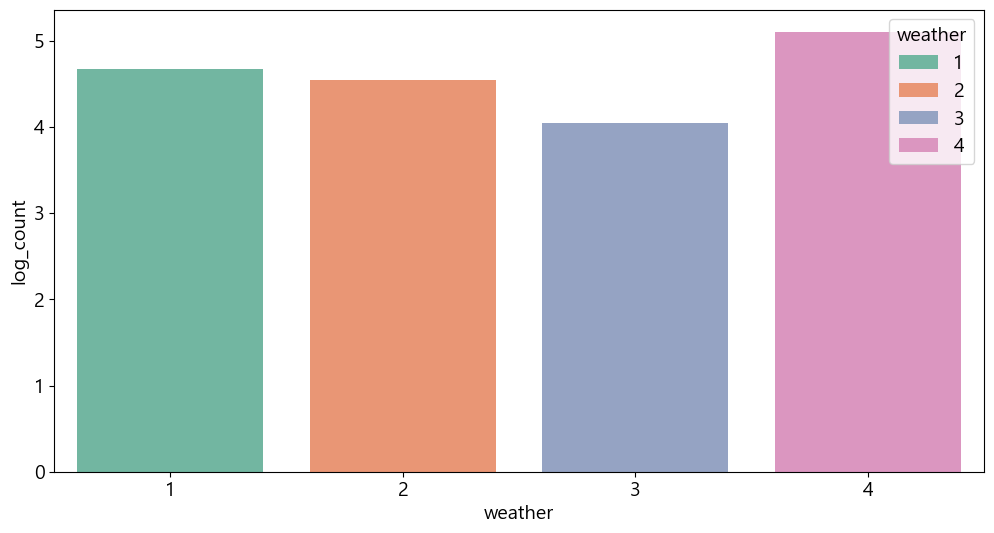

In [29]:
# weateher 별 log_count의 평균 시각화
a1 = train_df.groupby('weather', as_index=False)['log_count'].mean()

a2 = a1.sort_values('log_count', ascending=False)
display(a2)

sns.barplot(data=a1, x='weather', y='log_count', palette='Set2', hue='weather')
plt.show()

### 표본의 함정
- 통계정 유의성 부재
- 날씨 4번의 데이터는 전체 약 10,000건 중 단 1건에 불과하여 통계적으로 유의미한 평균값이라고 볼 수 없다.
- 제거한거나 편입을 시켜야 한다.

In [30]:
test_df['weather'].value_counts()

weather
1    4221
2    1710
3     560
4       2
Name: count, dtype: int64

In [31]:
# 예측해야할 데이터에 4가 있으므로 3에 편입한다.
idx1 = train_df.query('weather == 4').index
idx2 = test_df.query('weather == 4').index

train_df.loc[idx1, 'weather'] = 3
test_df.loc[idx2, 'weather'] = 3

In [32]:
display(train_df['weather'].value_counts())
display(test_df['weather'].value_counts())

weather
1    7192
2    2834
3     860
Name: count, dtype: int64

weather
1    4221
2    1710
3     562
Name: count, dtype: int64

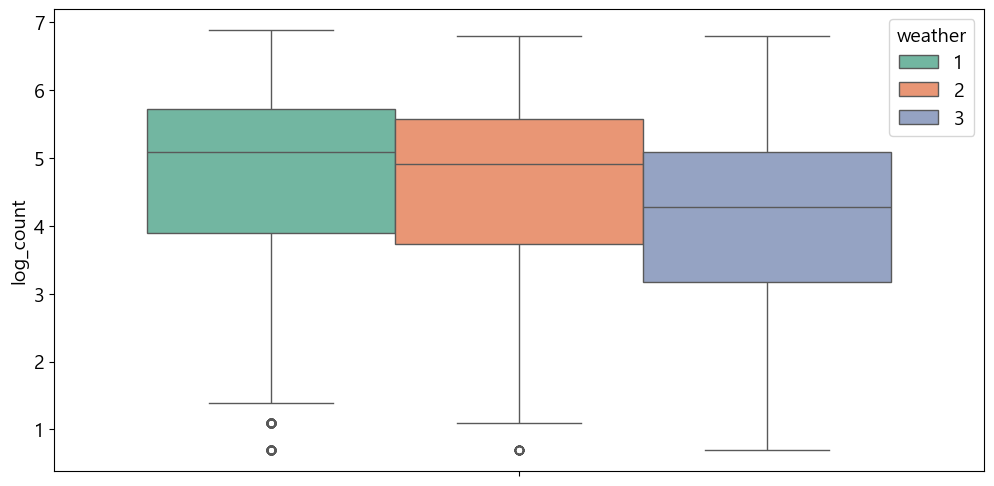

In [33]:
# weather를 활용하여 boxplot을 그려본다.
sns.boxplot(data=train_df, y='log_count', hue='weather', palette='Set2')
plt.show()

,weather,log_count
0,1,4.673980
1,2,4.545450
2,3,4.051761


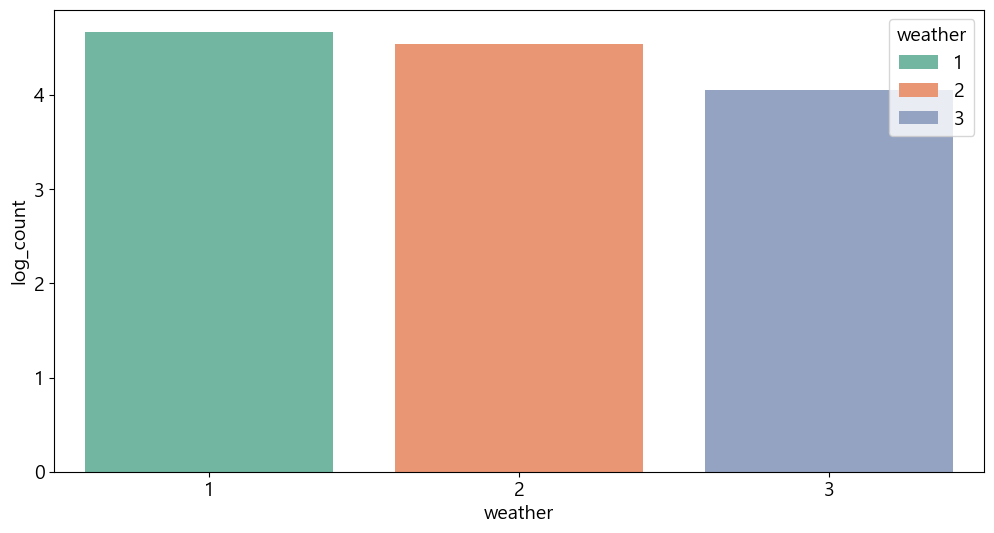

In [34]:
# weather 별 log_count의 평균 시각화
a1 = train_df.groupby('weather', as_index=False)['log_count'].mean()

a2 = a1.sort_values('log_count', ascending=False)
display(a2)

sns.barplot(data=a1, x='weather', y='log_count', palette='Set2', hue='weather')
plt.show()

- 날씨가 좋을 수록 자전거 대여 횟수는 증가한다.

### temp
- 기온, 섭씨온도

In [35]:
# 히스토 그램 데이터를 가져온다.
a1 = np.histogram(train_df['temp'], bins=10)

index_list = []

for v1 in range(len(a1[1]) - 1) :
    if v1 == len(a1[1]) - 2 :
        index_list.append(f'{a1[1][v1]:.3f}이상 {a1[1][v1 + 1]:.3f}이하')
    else :
        index_list.append(f'{a1[1][v1]:.3f}이상 {a1[1][v1 + 1]:.3f}미만')

pd.DataFrame(a1[0], index=index_list, columns=['데이터 수'])

,데이터 수
0.820이상 4.838미만,69
4.838이상 8.856미만,648
8.856이상 12.874미만,1440
12.874이상 16.892미만,1891
16.892이상 20.910미만,1587
20.910이상 24.928미만,1753
24.928이상 28.946미만,1901
28.946이상 32.964미만,1194
32.964이상 36.982미만,355
36.982이상 41.000이하,48


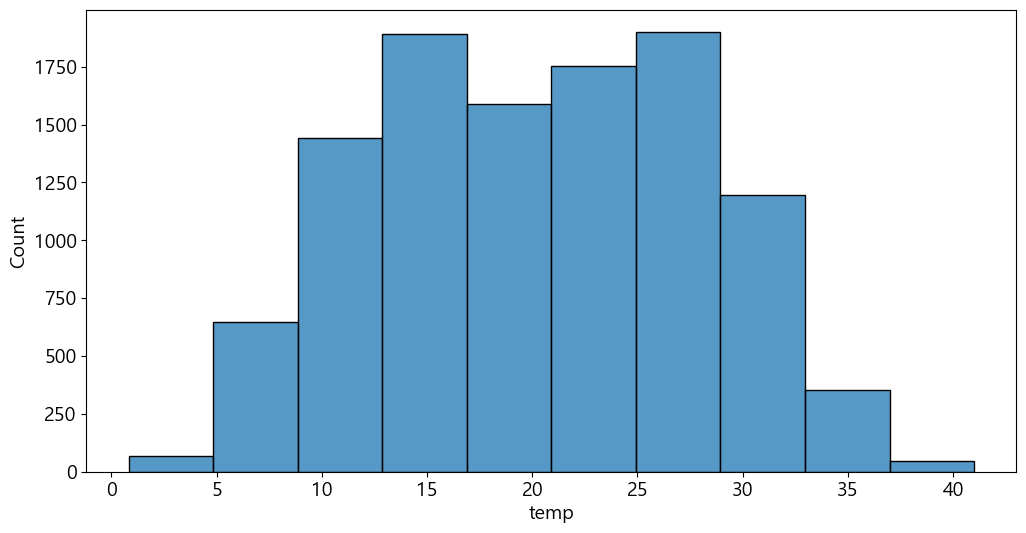

In [36]:
sns.histplot(data=train_df, x='temp', bins=10)
plt.show()

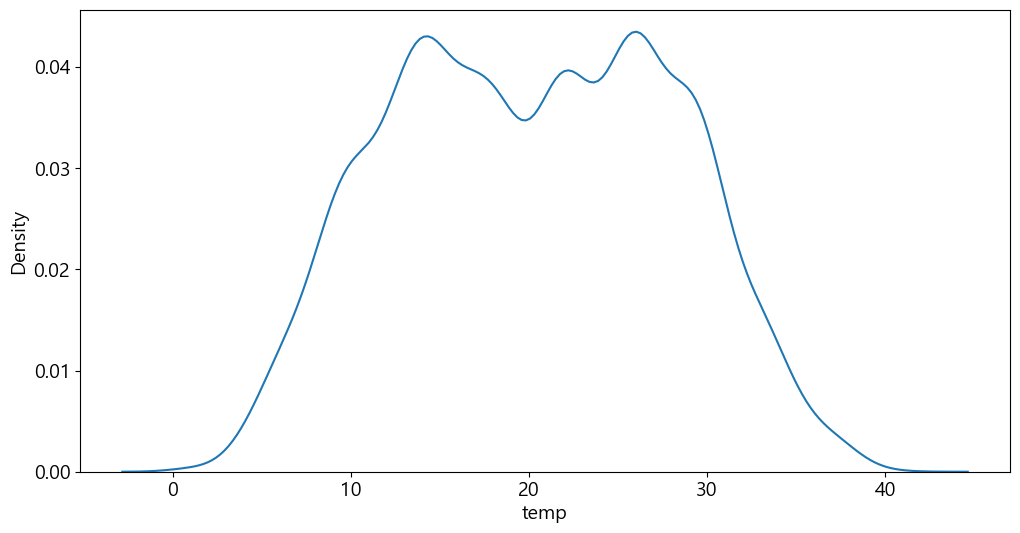

In [37]:
sns.kdeplot(data=train_df, x='temp')
plt.show()

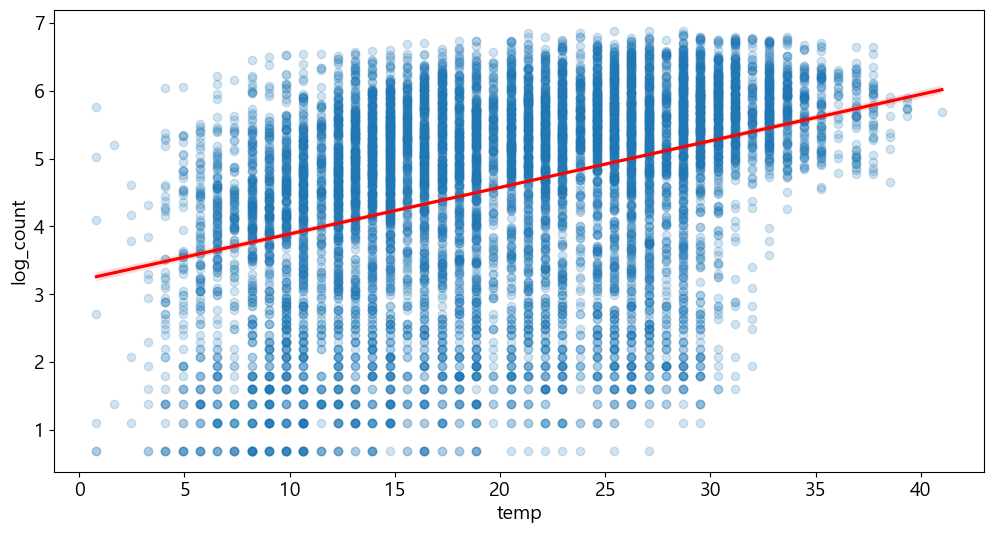

In [38]:
# 산점도와 회귀선 그리기
# 전체적인 데이터의 흐름과 상관관계를 한눈에 파악할 때 사용한다.
# 회귀선을 추가하면 추세를 쉽게 알 수 있다.
sns.regplot(data=train_df, x='temp', y='log_count',
           scatter_kws={'alpha':0.2},
           line_kws={'color':'red'})
plt.show()

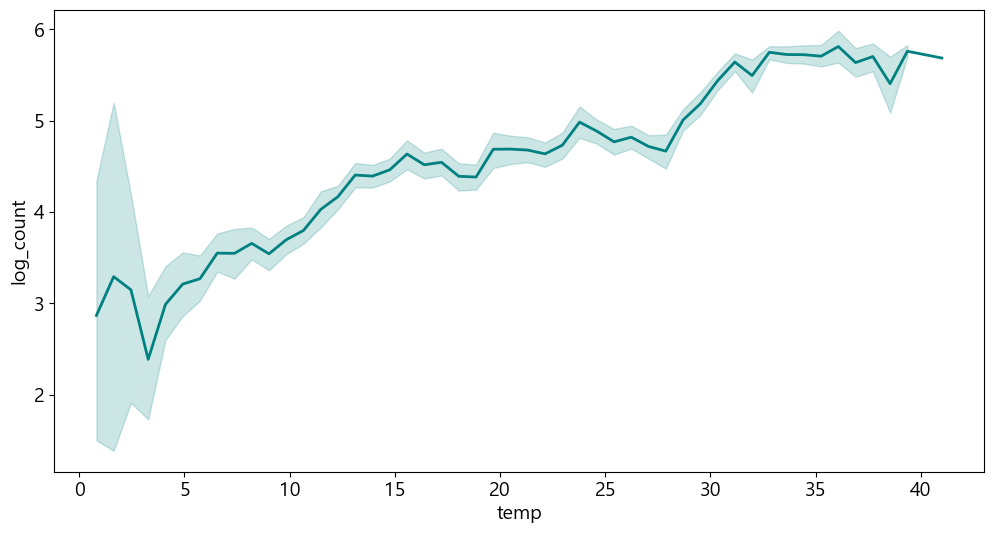

In [39]:
sns.lineplot(x='temp', y='log_count', data=train_df, color='teal', linewidth=2)
plt.show()

- 온도가 높을 수록 자전거 대여 횟수는 증가한다.

### atemp
- 체감 온도, 섭씨 온도

In [40]:
a1 = np.histogram(train_df['atemp'], bins=10)
index_list = []
for v1 in range(len(a1[1]) - 1) :
    if v1 == len(a1[1]) - 2 :
        index_list.append(f'{a1[1][v1]:.3f}이상 {a1[1][v1 + 1]:.3f}이하')
    else :
        index_list.append(f'{a1[1][v1]:.3f}이상 {a1[1][v1 + 1]:.3f}미만')

pd.DataFrame(a1[0], index=index_list, columns=['데이터수'])

,데이터수
0.760이상 5.229미만,44
5.229이상 9.699미만,406
9.699이상 14.168미만,1243
14.168이상 18.638미만,1679
18.638이상 23.108미만,1790
23.108이상 27.577미만,1962
27.577이상 32.047미만,1832
32.047이상 36.516미만,1425
36.516이상 40.985미만,440
40.985이상 45.455이하,65


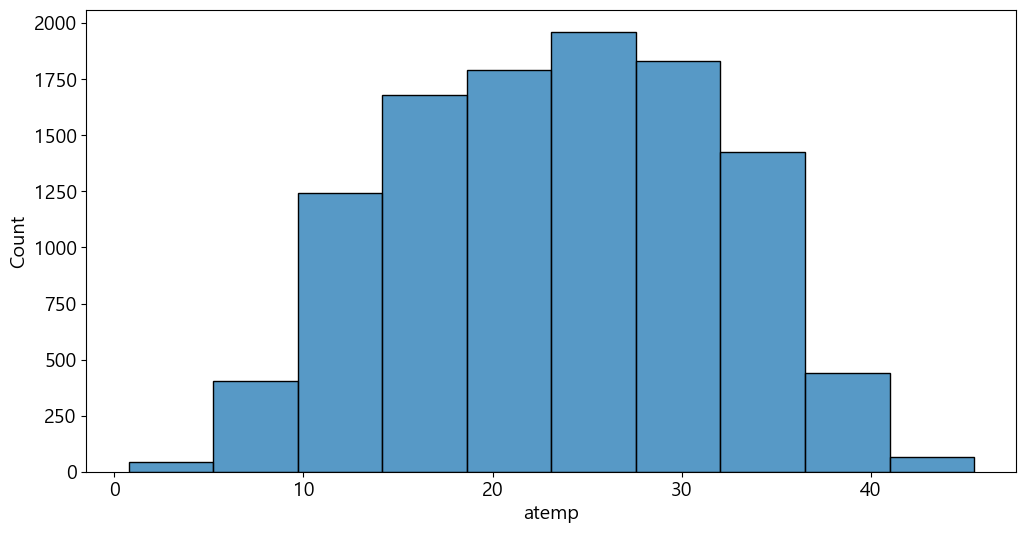

In [41]:
sns.histplot(data=train_df, x='atemp', bins=10)
plt.show()

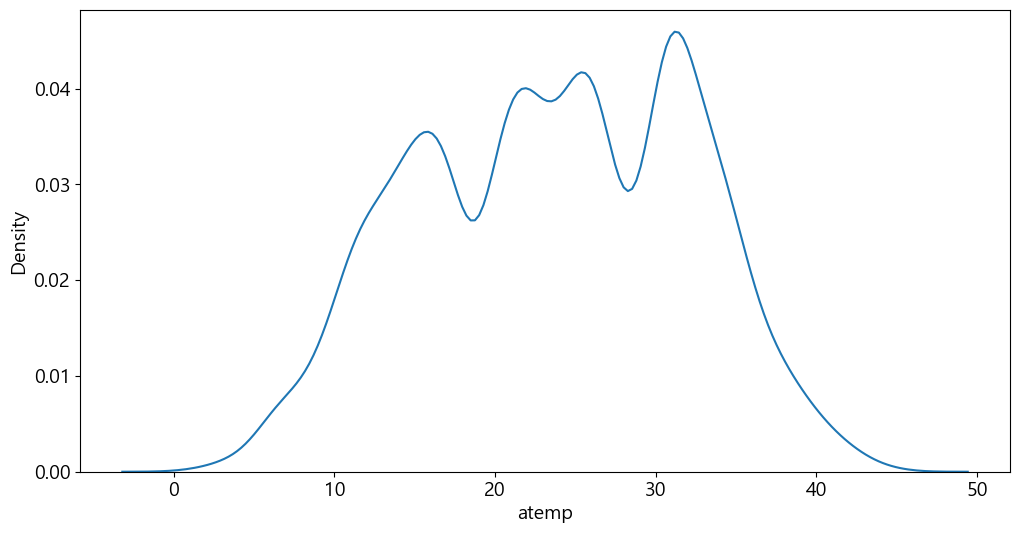

In [42]:
sns.kdeplot(data=train_df, x='atemp')
plt.show()

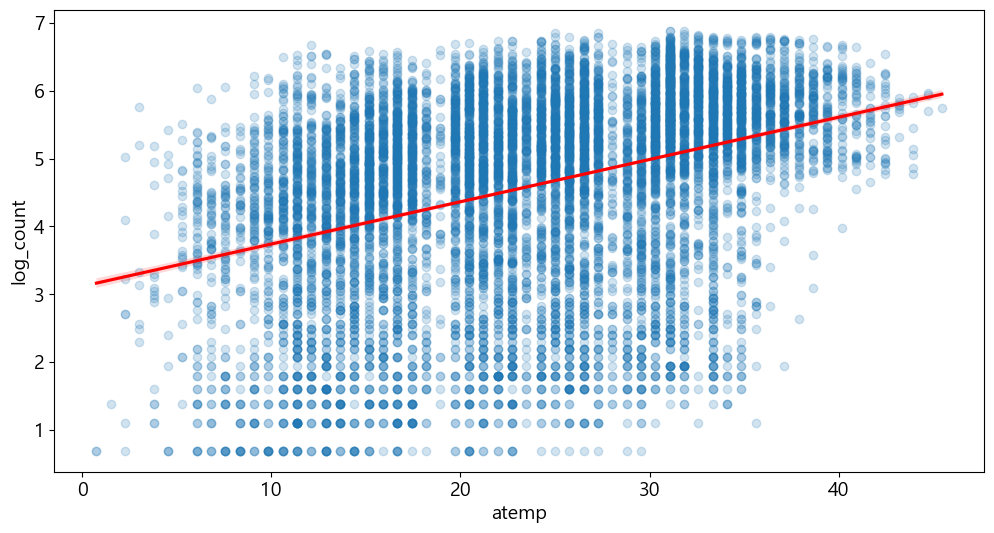

In [43]:
sns.regplot(x='atemp', y='log_count', data=train_df,
            scatter_kws={'alpha' : 0.2},
            line_kws={'color':'red'})
plt.show()

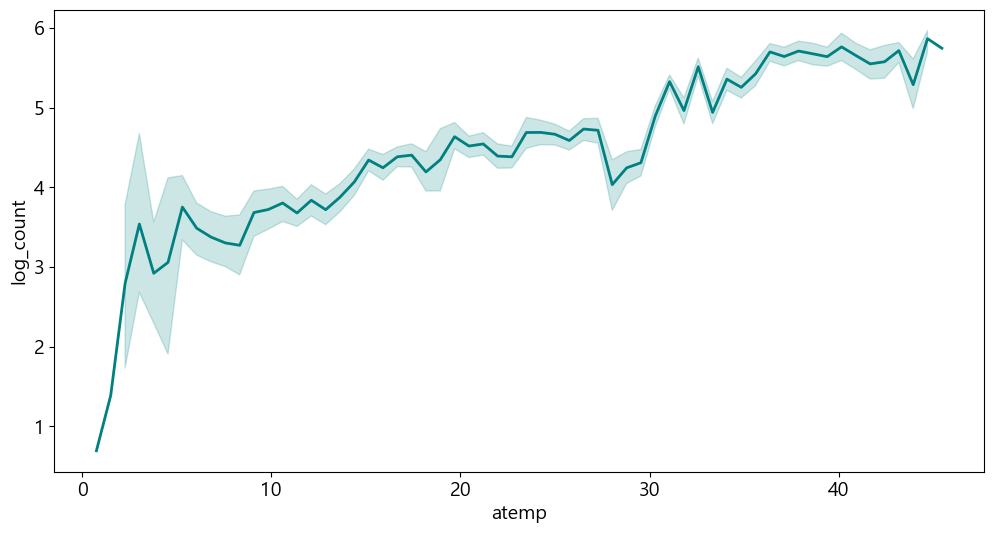

In [44]:
sns.lineplot(x='atemp', y='log_count', data=train_df, color='teal', linewidth=2)
plt.show()

- 체감온도가 상승하면 자전거 대여 횟수도 증가한다

### humidity 분석
- 습도

In [45]:
a1 = np.histogram(train_df['humidity'], bins=10)
index_list = []

for v1 in range(len(a1[1]) - 1) :
    if v1 == len(a1[1]) - 2 :
        index_list.append(f'{a1[1][v1]:.3f}이상 {a1[1][v1 + 1]:.3f}이하')
    else :
        index_list.append(f'{a1[1][v1]:.3f}이상 {a1[1][v1 + 1]:.3f}미만')

pd.DataFrame(a1[0], index=index_list, columns=['데이터수'])

,데이터수
0.000이상 10.000미만,23
10.000이상 20.000미만,45
20.000이상 30.000미만,364
30.000이상 40.000미만,1039
40.000이상 50.000미만,1727
50.000이상 60.000미만,1842
60.000이상 70.000미만,1748
70.000이상 80.000미만,1736
80.000이상 90.000미만,1676
90.000이상 100.000이하,686


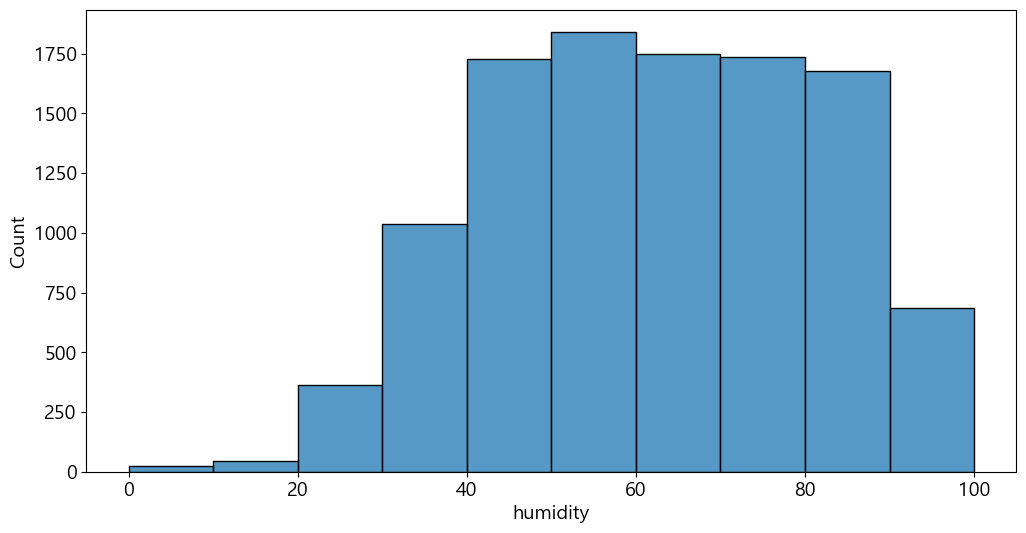

In [46]:
sns.histplot(data=train_df, x='humidity', bins=10)
plt.show()

In [47]:
# 왜도 계산 (0에 가까울 수록 정규분포, 1 이상이면 왜도가 심함)
skew_hum = train_df['humidity'].skew()
print(f'습도의 왜도 : {skew_hum:.2f}')

습도의 왜도 : -0.09


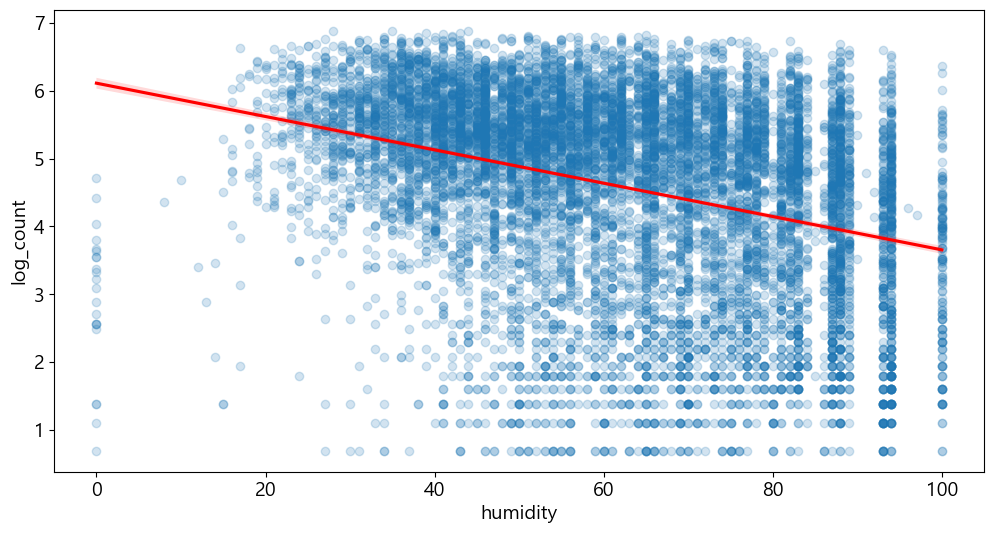

In [48]:
sns.regplot(x='humidity', y='log_count', data=train_df,
            scatter_kws={'alpha':0.2},
            line_kws={'color':'red'})
plt.show()

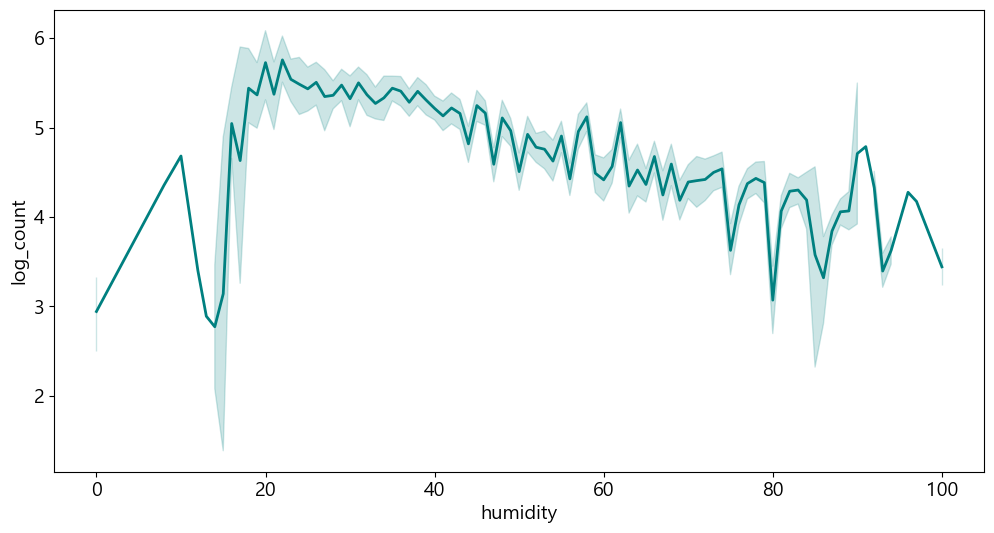

In [49]:
sns.lineplot(x='humidity', y='log_count', data=train_df, color='teal', linewidth=2)
plt.show()

- 습도가 올라갈 수록 자전거 대여 수는 감소한다.

### windspeed
- 풍속

In [50]:
a1 = np.histogram(train_df['windspeed'], bins=10)
index_list = []
for v1 in range(len(a1[1]) - 1) :
    if v1 == len(a1[1]) - 2 :
        index_list.append(f'{a1[1][v1]:.3f}이상 {a1[1][v1 + 1]:.3f}이하')
    else :
        index_list.append(f'{a1[1][v1]:.3f}이상 {a1[1][v1 + 1]:.3f}미만')
pd.DataFrame(a1[0], index=index_list, columns=['데이터수'])

,데이터수
0.000이상 5.700미만,1313
5.700이상 11.399미만,4083
11.399이상 17.099미만,2827
17.099이상 22.799미만,1540
22.799이상 28.498미만,696
28.498이상 34.198미만,280
34.198이상 39.898미만,107
39.898이상 45.598미만,31
45.598이상 51.297미만,6
51.297이상 56.997이하,3


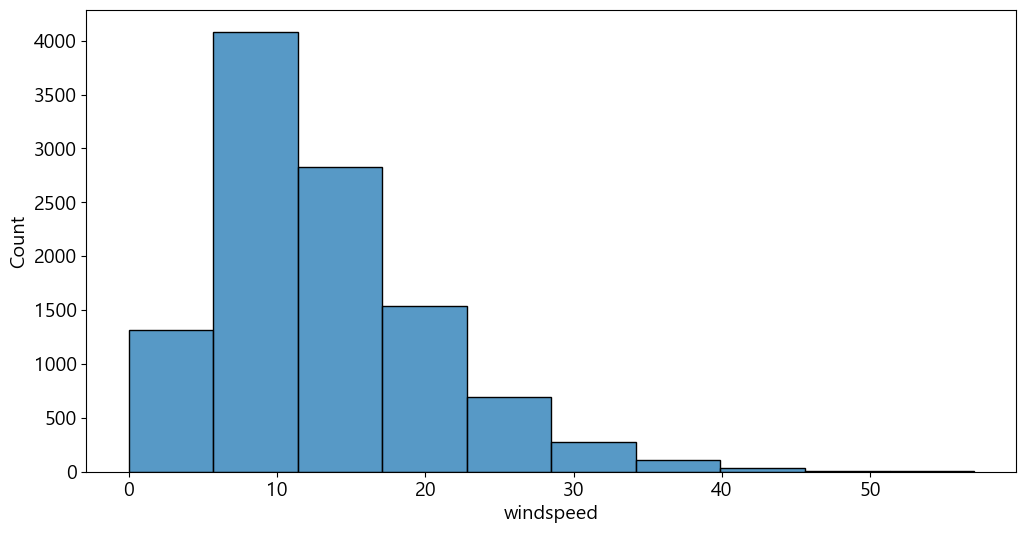

In [51]:
sns.histplot(data=train_df, x='windspeed', bins=10)
plt.show()

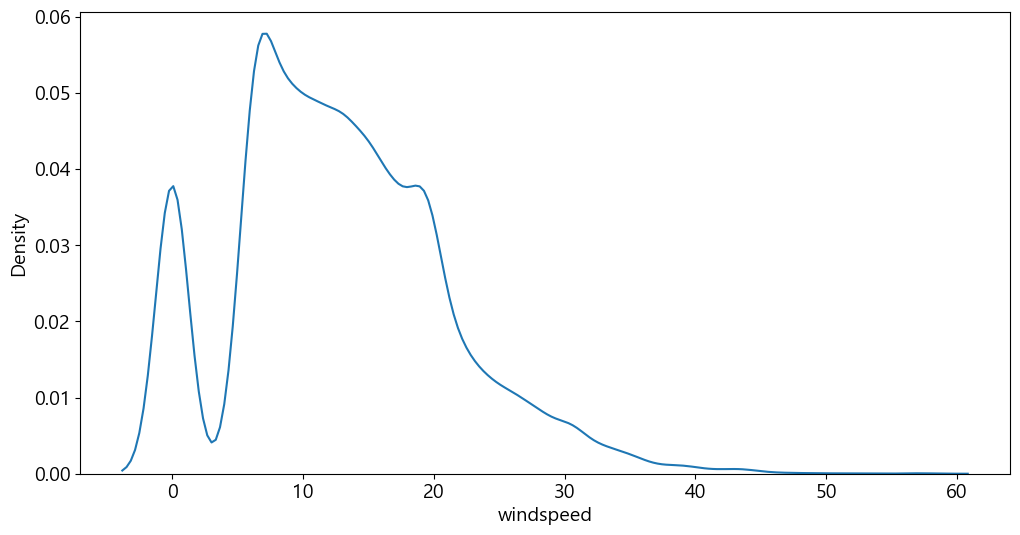

In [52]:
sns.kdeplot(data=train_df, x='windspeed')
plt.show()

In [53]:
# 왜도 계산
skew_wind = train_df['windspeed'].skew()
print(f'바람세기 왜도 : {skew_wind:.2f}')

바람세기 왜도 : 0.59


In [54]:
# 로그값을 취한 컬럼을 추가한다.
train_df['log_windspeed'] = np.log1p(train_df['windspeed'])
test_df['log_windspeed'] = np.log1p(test_df['windspeed'])

In [55]:
train_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,log_count,year,month,day,hour,log_windspeed
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,16,2.833213,2011,1,1,0,0.000000
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,40,3.713572,2011,1,1,1,0.000000
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,32,3.496508,2011,1,1,2,0.000000
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,13,2.639057,2011,1,1,3,0.000000
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,1,0.693147,2011,1,1,4,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,336,5.820083,2012,12,19,19,3.295937
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,241,5.488938,2012,12,19,20,2.772670
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,168,5.129899,2012,12,19,21,2.772670
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,129,4.867534,2012,12,19,22,1.946367


In [56]:
test_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour,log_windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027,2011,1,20,0,3.295937
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,1,0.000000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,2,0.000000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,3,2.485023
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,4,2.485023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6488,2012-12-31 19:00:00,1,0,1,2,10.66,12.880,60,11.0014,2012,12,31,19,2.485023
6489,2012-12-31 20:00:00,1,0,1,2,10.66,12.880,60,11.0014,2012,12,31,20,2.485023
6490,2012-12-31 21:00:00,1,0,1,1,10.66,12.880,60,11.0014,2012,12,31,21,2.485023
6491,2012-12-31 22:00:00,1,0,1,1,10.66,13.635,56,8.9981,2012,12,31,22,2.302395


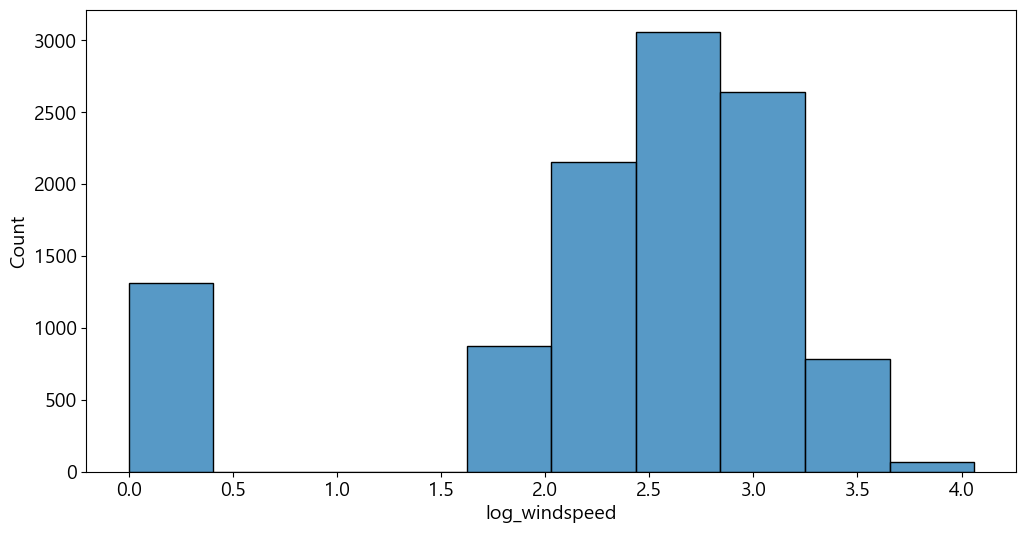

In [57]:
sns.histplot(data=train_df, x='log_windspeed', bins=10)
plt.show()

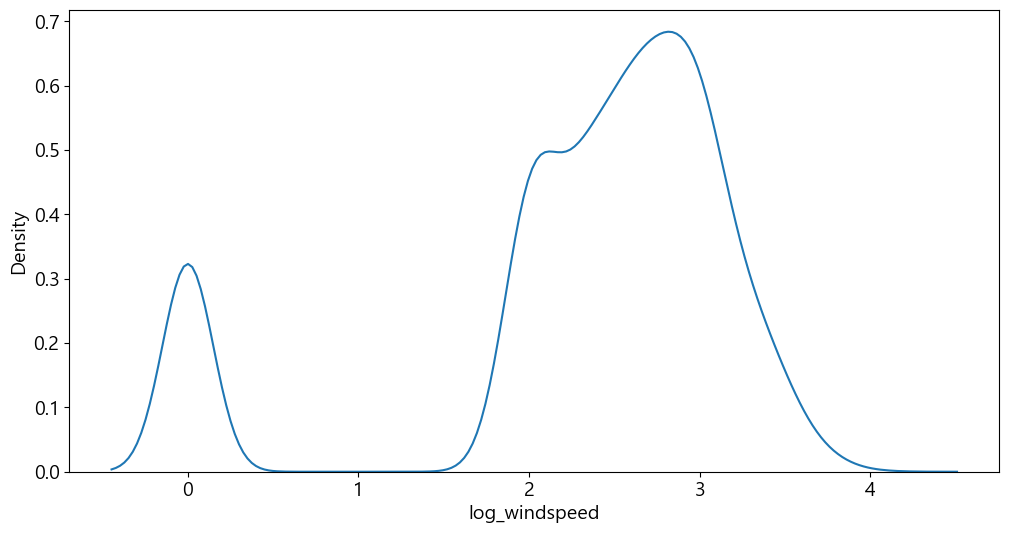

In [58]:
sns.kdeplot(data=train_df, x='log_windspeed')
plt.show()

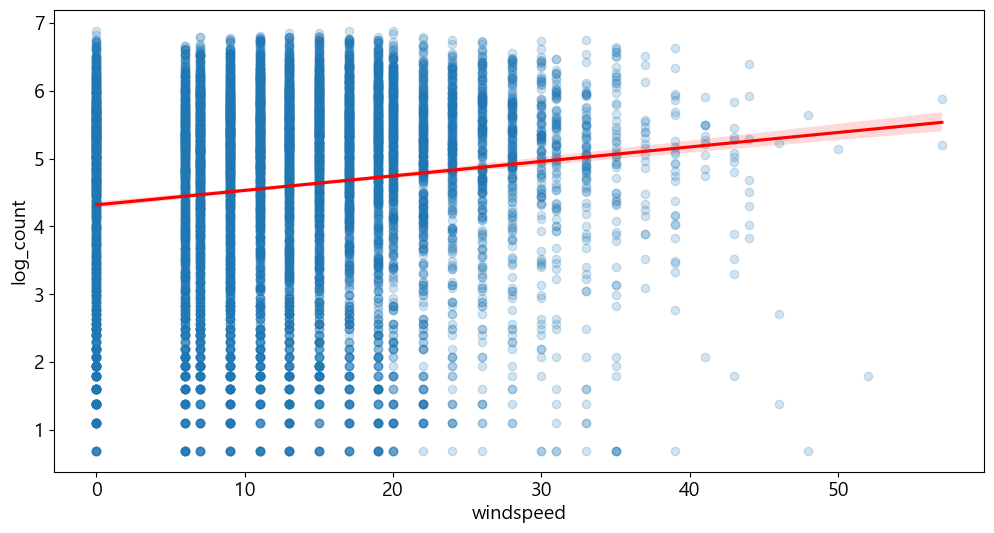

In [59]:
# windspeed의 산점도와 회귀선
sns.regplot(x='windspeed', y='log_count', data=train_df,
            scatter_kws={'alpha' : 0.2},
            line_kws={'color' : 'red'})
plt.show()

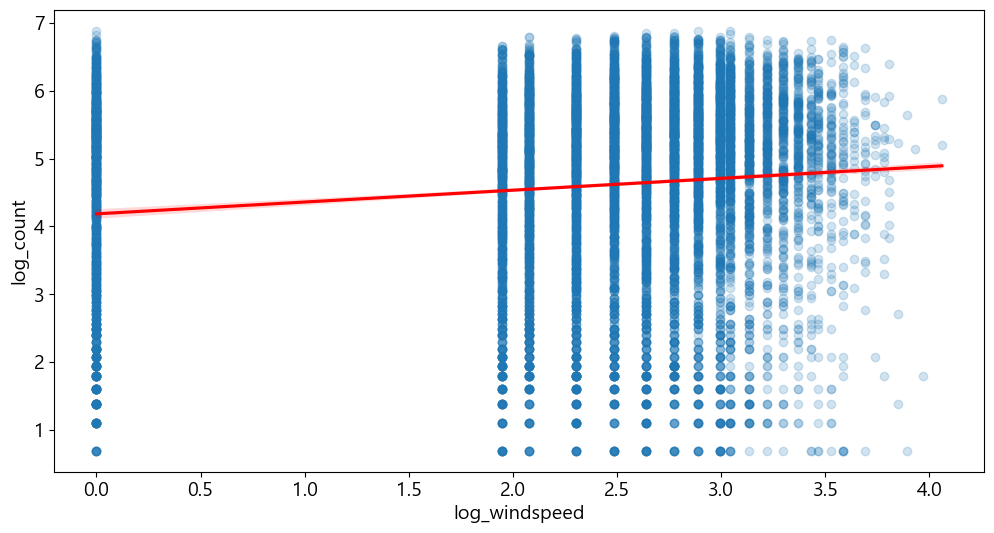

In [60]:
# log_windspeed 의 산점도와 회귀선
sns.regplot(x='log_windspeed', y='log_count', data=train_df,
            scatter_kws={'alpha' : 0.2},
            line_kws={'color' : 'red'})
plt.show()

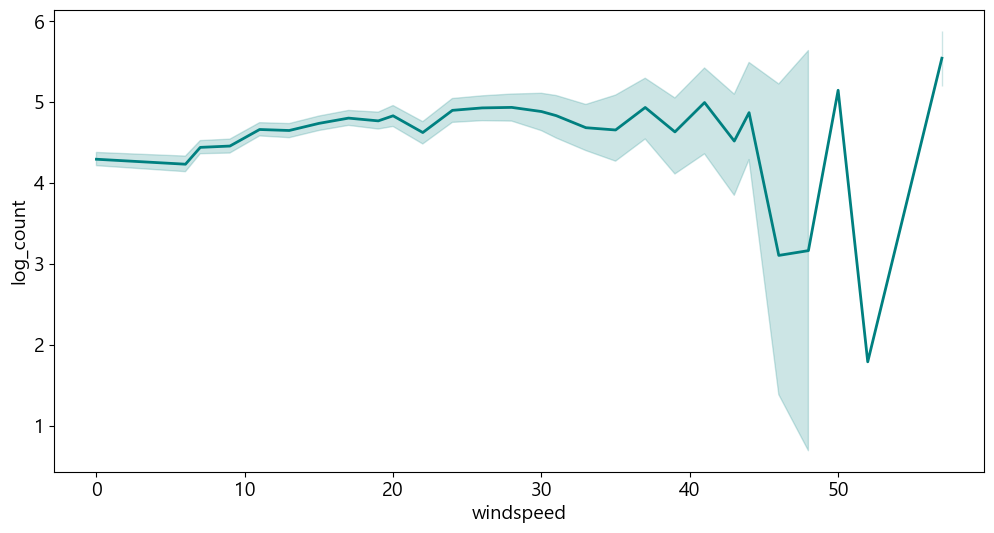

In [61]:
# windspeed의 평균 선
sns.lineplot(x='windspeed', y='log_count', data=train_df, color='teal', linewidth=2)
plt.show()

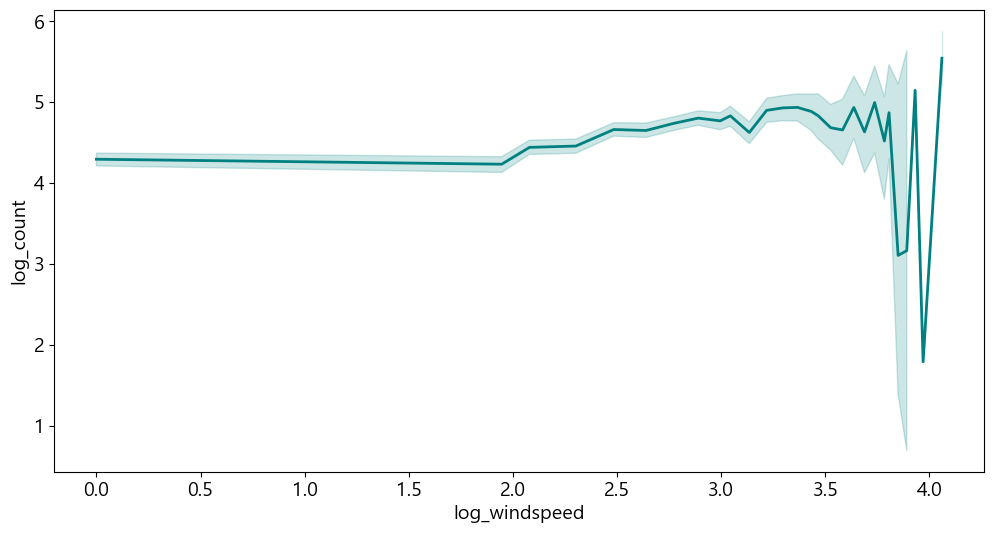

In [62]:
# log_windspeed
sns.lineplot(x='log_windspeed', y='log_count', data=train_df, color='teal', linewidth=2)
plt.show()

- windspeed가 증가할 수 록 자전거 대여수도 증가한다.

### year

In [63]:
train_df['year'].value_counts()

year
2012    5464
2011    5422
Name: count, dtype: int64

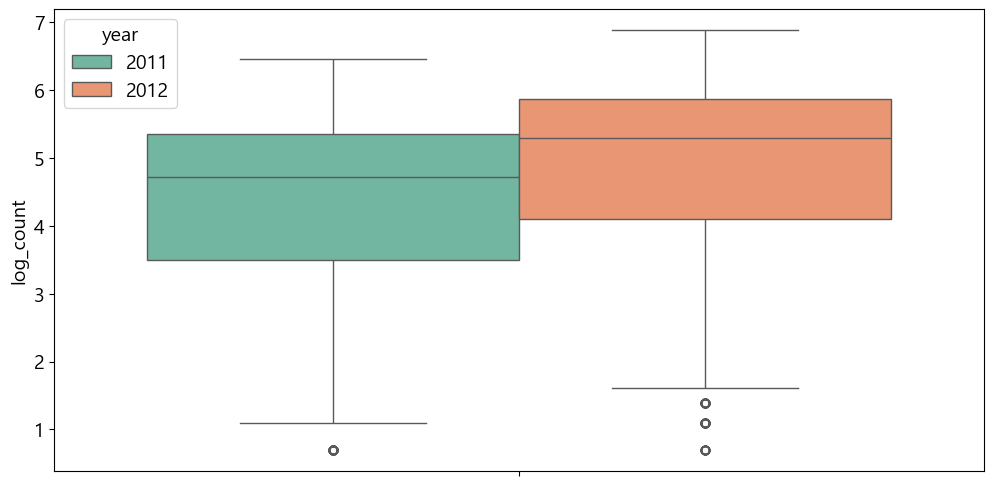

In [64]:
# year를 활용하여 boxplot을 그려본다.
sns.boxplot(data=train_df, y='log_count', hue='year', palette='Set2')
plt.show()

,year,log_count
1,2012,4.843376
0,2011,4.337399


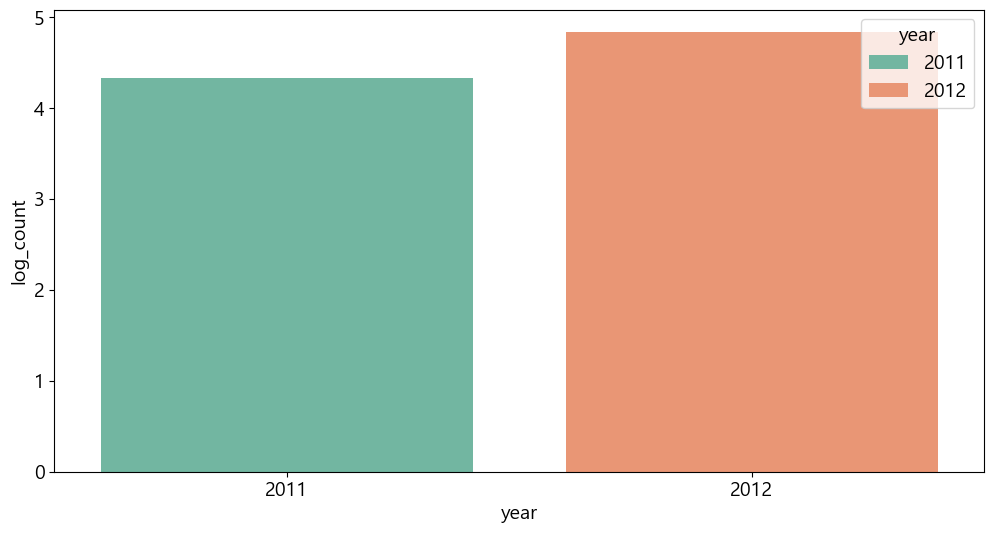

In [65]:
# yaer별 log_count 평균 시각화
a1 = train_df.groupby('year', as_index=False)['log_count'].mean()

a2 = a1.sort_values('log_count', ascending=False)
display(a2)

sns.barplot(data=a1, x='year', y='log_count', palette='Set2', hue='year')
plt.show()

- 2011년에 비해 2012년에 자전거 대여 횟수가 증가하였다.

### month

In [66]:
train_df['month'].value_counts()

month
5     912
6     912
7     912
8     912
12    912
10    911
11    911
4     909
9     909
2     901
3     901
1     884
Name: count, dtype: int64

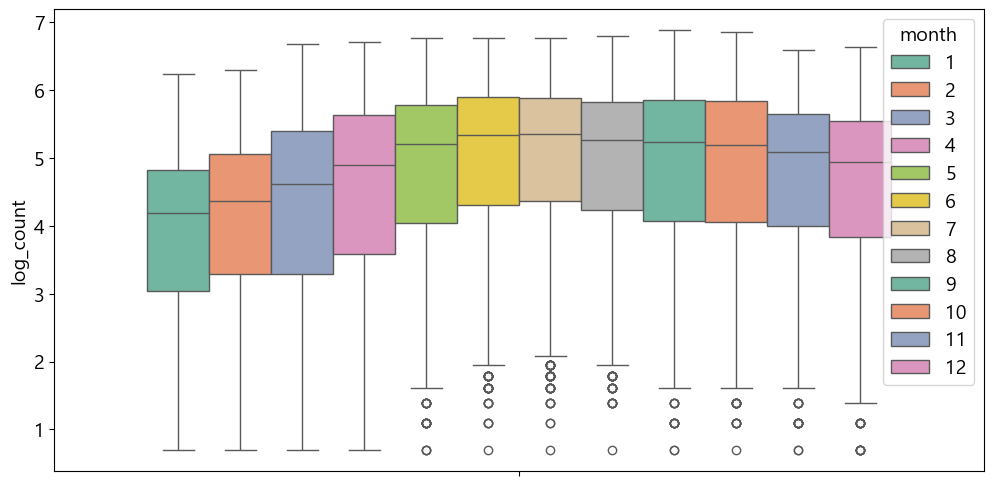

In [67]:
# month를 활용하여 boxplot을 그려본다.
sns.boxplot(data=train_df, y='log_count', hue='month', palette='Set2')
plt.show()

,month,log_count
6,7,4.928314
5,6,4.917041
7,8,4.887959
8,9,4.839759
9,10,4.812821
4,5,4.786222
10,11,4.679616
11,12,4.561363
3,4,4.504310
2,3,4.250942


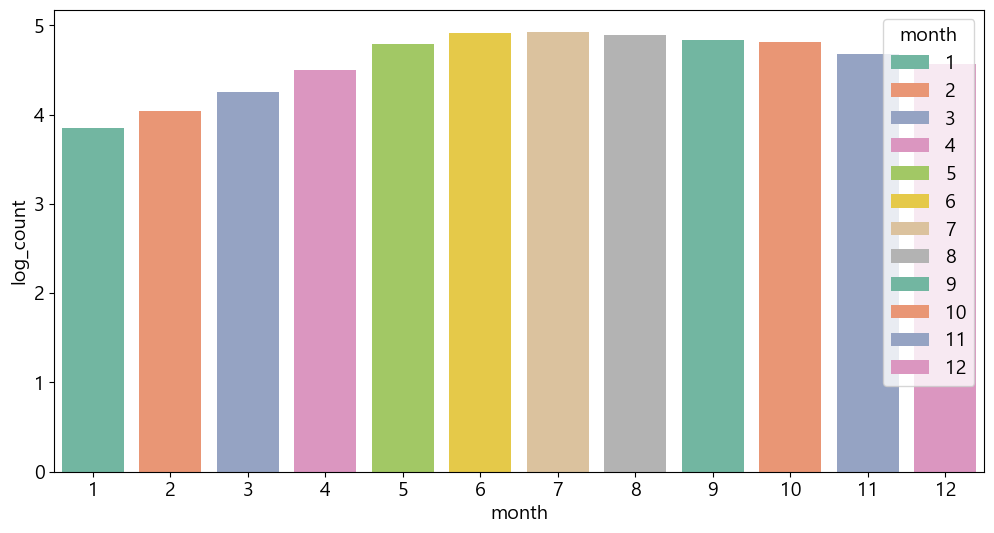

In [68]:
# month 별 log_count의 평균 시각화
a1 = train_df.groupby('month', as_index=False)['log_count'].mean()
a2 = a1.sort_values('log_count', ascending=False)
display(a2)

sns.barplot(data=a1, x='month', y='log_count', palette='Set2', hue='month')
plt.show()

- 1월이 가장 낮고 월이 증가할 수록 증가하다가 11월 부터 감소 추세를 보인다.

### day

In [69]:
train_df['day'].value_counts()

day
1     575
5     575
9     575
17    575
4     574
7     574
8     574
13    574
14    574
15    574
16    574
19    574
2     573
3     573
12    573
6     572
10    572
11    568
18    563
Name: count, dtype: int64

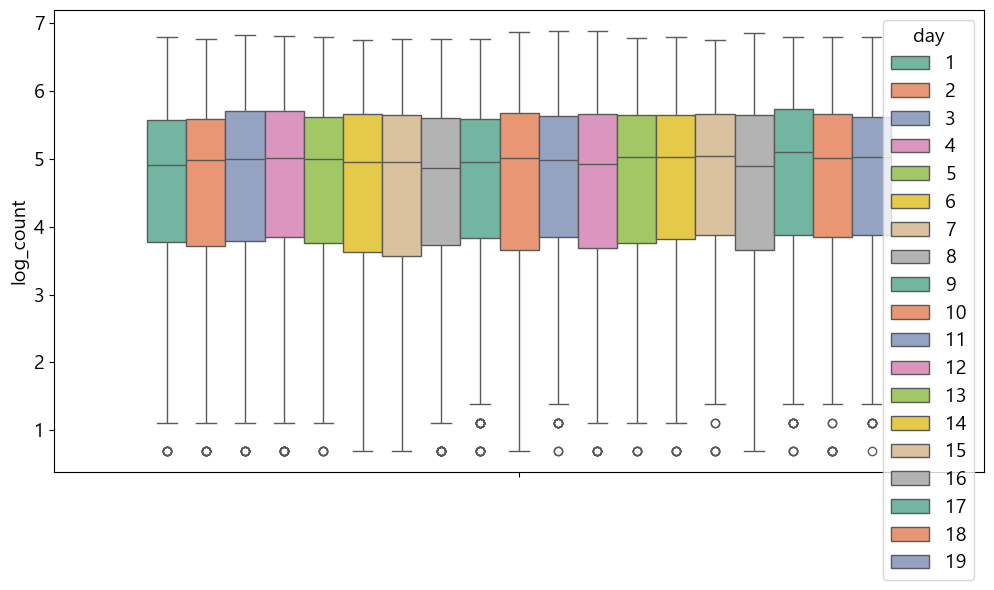

In [70]:
# day를 활용하여 boxplot을 그려본다.
sns.boxplot(data=train_df, y='log_count', hue='day', palette='Set2')
plt.show()

,day,log_count
16,17,4.673950
14,15,4.673179
17,18,4.648012
10,11,4.635093
13,14,4.616197
18,19,4.615717
3,4,4.607368
12,13,4.598360
2,3,4.597414
9,10,4.588190


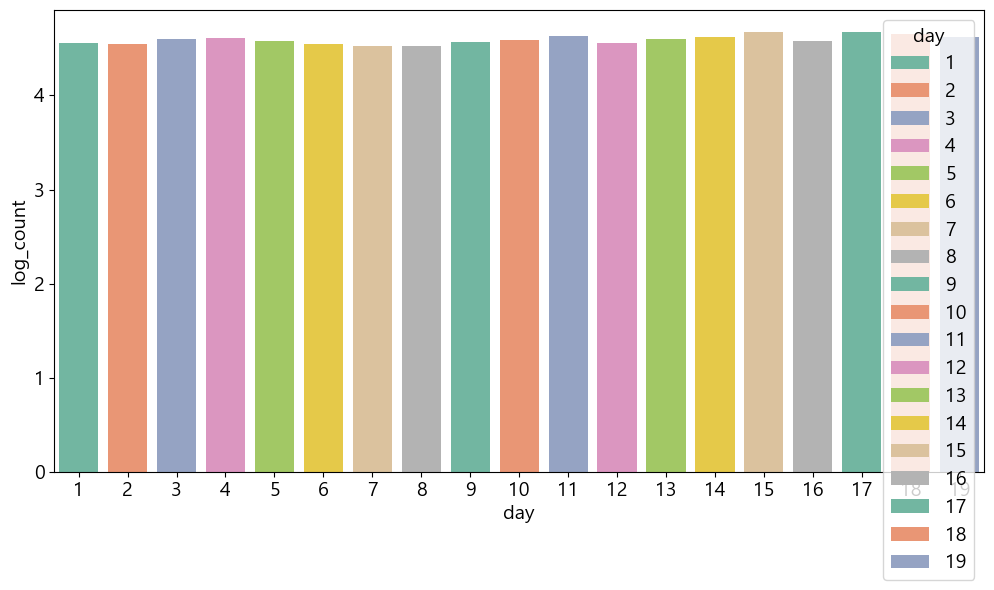

In [71]:
a1 = train_df.groupby('day', as_index=False)['log_count'].mean()
a2 = a1.sort_values('log_count', ascending=False)
display(a2)

sns.barplot(data=a1, x='day', y='log_count', palette='Set2', hue='day')
plt.show()

- day와 자전거 대여 횟수는 관계가 없다.

### hour

In [72]:
train_df['hour'].value_counts()

hour
12    456
13    456
14    456
15    456
16    456
17    456
18    456
19    456
20    456
21    456
22    456
23    456
0     455
6     455
7     455
8     455
9     455
10    455
11    455
1     454
5     452
2     448
4     442
3     433
Name: count, dtype: int64

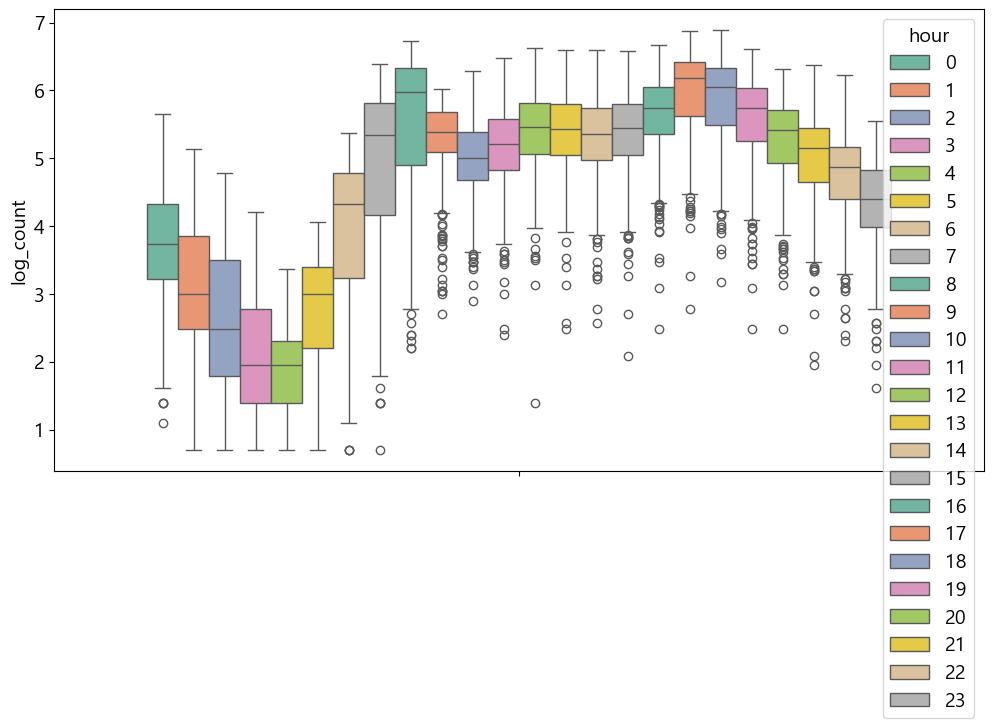

In [73]:
# hour를 활용하여 boxplot을 구려본다.
sns.boxplot(data=train_df, y='log_count', hue='hour', palette='Set2')
plt.show()

,hour,log_count
17,17,6.000667
18,18,5.898224
16,16,5.617140
19,19,5.591497
8,8,5.575184
13,13,5.377655
12,12,5.374850
15,15,5.359728
14,14,5.304810
9,9,5.284876


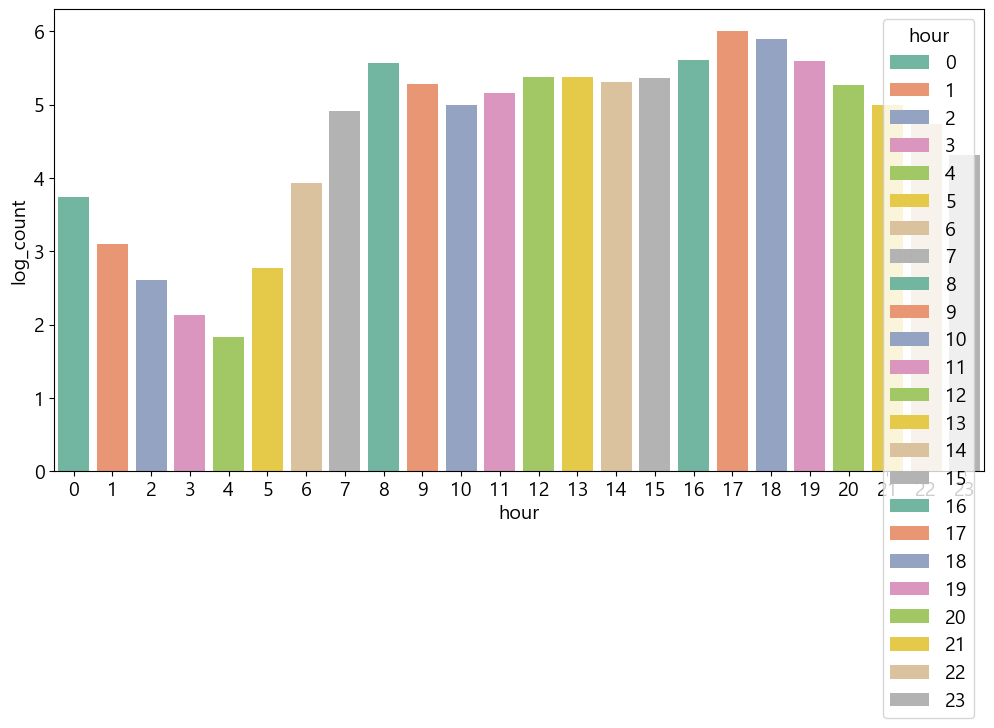

In [74]:
# hour의 평균 시각화
a1 = train_df.groupby('hour', as_index=False)['log_count'].mean()
a2 = a1.sort_values('log_count', ascending=False)
display(a2)

sns.barplot(data=a1, x='hour', y='log_count', palette='Set2', hue='hour')
plt.show()

- 오전 5시 부터 자전거 대여수가 증가하다가 9시쯤에 정점을 찍고 살짝 감소한 상태로 유지된다.
- 오후 4시 부터 자전거 대여수가 증가하다가 6시쯤에 정점을 찍고 눈에 띄가 감소한다.

### 불필요한 컬럼 제거

In [75]:
train_df.drop(['datetime', 'count'], axis=1, inplace=True)
test_df.drop(['datetime'], axis=1, inplace=True)

In [76]:
train_df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,log_count,year,month,day,hour,log_windspeed
0,1,0,0,1,9.84,14.395,81,0.0000,2.833213,2011,1,1,0,0.000000
1,1,0,0,1,9.02,13.635,80,0.0000,3.713572,2011,1,1,1,0.000000
2,1,0,0,1,9.02,13.635,80,0.0000,3.496508,2011,1,1,2,0.000000
3,1,0,0,1,9.84,14.395,75,0.0000,2.639057,2011,1,1,3,0.000000
4,1,0,0,1,9.84,14.395,75,0.0000,0.693147,2011,1,1,4,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,4,0,1,1,15.58,19.695,50,26.0027,5.820083,2012,12,19,19,3.295937
10882,4,0,1,1,14.76,17.425,57,15.0013,5.488938,2012,12,19,20,2.772670
10883,4,0,1,1,13.94,15.910,61,15.0013,5.129899,2012,12,19,21,2.772670
10884,4,0,1,1,13.94,17.425,61,6.0032,4.867534,2012,12,19,22,1.946367


In [77]:
test_df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour,log_windspeed
0,1,0,1,1,10.66,11.365,56,26.0027,2011,1,20,0,3.295937
1,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,1,0.000000
2,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,2,0.000000
3,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,3,2.485023
4,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,4,2.485023
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6488,1,0,1,2,10.66,12.880,60,11.0014,2012,12,31,19,2.485023
6489,1,0,1,2,10.66,12.880,60,11.0014,2012,12,31,20,2.485023
6490,1,0,1,1,10.66,12.880,60,11.0014,2012,12,31,21,2.485023
6491,1,0,1,1,10.66,13.635,56,8.9981,2012,12,31,22,2.302395


In [78]:
train_df.to_csv('data/bike_sharing_train2.csv', index=False)
test_df.to_csv('data/bike_sharing_test2.csv', index=False)